# GA-DKL: Closed-Loop Discovery of Processing Protocols (Experimental Workflow)

This notebook implements the closed-loop workflow described in *"Closed-loop discovery of out-of-distribution processing protocols by evolutionary search and uncertainty-aware learning."* It treats the scanning-probe tip-bias waveform as the processing protocol and the change in the effective nonlinear electromechanical response (ENL) of a ferroelectric thin film as the experimental reward.

**Workflow overview**

1. Define the ENL metric and the small-signal readout waveform.
2. Construct 14 experimentally common seed waveforms.
3. Train a variational autoencoder (VAE) on the seeds and decode a latent grid of candidate waveforms (the initialization manifold).
4. Connect to the microscope (Asylum Research SPM via [`aespm`](https://github.com/RichardLiuCoding/aespm)) and define the measurement primitives.
5. Define the deep kernel learning (DKL) surrogate: 1D CNN feature extractor + exact Gaussian process.
6. Define the genetic algorithm (GA) operating on a 33-parameter Fourier genotype (DC + 16 harmonics).
7. Run the initial seeding experiment (64 waveforms sampled from the VAE grid).
8. Run the GA-DKL active-learning loop: retrain DKL, generate ~1,000 GA candidates, rank by upper confidence bound (UCB), measure the selected batch, repeat.

**Requirements.** Sections 4, 7, and 8 require a live instrument connection and will not run offline. All other sections (waveform construction, VAE, DKL, GA) run on any machine; a fully self-contained version of the loop with a synthetic objective is provided in the Appendix. See `requirements.txt` for package versions.


## 1. Imports

In [1]:
import os
import time

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

# Instrument control (only needed for the experimental sections)
import aespm as ae
from igorwriter import IgorWave  # write waveforms as Igor .ibw


## 2. ENL metric

The effective nonlinear response (ENL) is defined as the deviation of the resonance-tracked piezoresponse-versus-drive curve from its low-drive linear trend (baseline fitted over the first `fraction` of the drive range). `lorentz` is used to fit the contact-resonance tuning curve at each drive voltage; `compute_nl` integrates the absolute deviation from the linear baseline. The optimization target is the post-/pre-waveform ENL ratio.

In [2]:
# Lorentzian model for the contact-resonance tuning curve
def lorentz(x, amp, center, width, offset):
    return amp / (1 + ((x - center) / width)**2) + offset


def compute_nl(x, y, fraction=1/3, order=1, num=100, show=False, norm=False):
    """Effective nonlinear response: integrated deviation of y(x) from the
    linear baseline fitted to the first `fraction` of the drive range.

    x : drive amplitudes (V), y : peak piezoresponse at each drive.
    """
    x_min, x_max = np.min(x), np.max(x)
    x_new = np.linspace(x_min, x_max, num=num)

    if x[-1] < x[0]:
        x_sorted, y_sorted = x[::-1], y[::-1]
    else:
        x_sorted, y_sorted = x, y

    param = np.polyfit(x_sorted[:int(len(x)*fraction)],
                       y_sorted[:int(len(x)*fraction)], order)
    y_fit = np.poly1d(param)(x_new)

    f = interp1d(x_sorted, y_sorted, kind='cubic', fill_value="extrapolate")
    y_interp = f(x_new)

    if show:
        plt.plot(x_new, y_interp)
        plt.plot(x_new, y_fit)

    if norm:
        return np.sum(np.abs(y_interp - y_fit)) / np.abs(param[0])
    return np.sum(np.abs(y_interp - y_fit))

## 3. Small-signal readout waveform

A repeated triangular sweep (0.1–1.3 V, well below the 2.5–3 V coercive voltage) used to read out the ENL before and after each candidate waveform.

Text(0, 0.5, 'V_drive (V)')

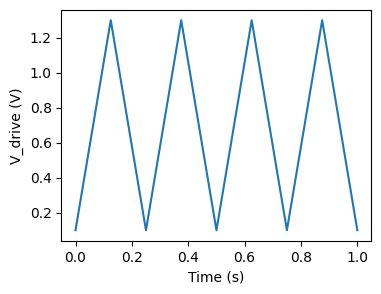

In [3]:
# Read out waveform

t0 = np.linspace(0, 1, 1024*1)

def func(x):
    return np.where(
        x < 0.5,
        0.1 + 1.2 / 0.5 * x,
        0.1 - 1.2 / 0.5 * (x - 1)
    )

wave_readout = func(t0)
wave_readout = np.concatenate([wave_readout,wave_readout,wave_readout,wave_readout])

t_new = np.linspace(0, 1, len(wave_readout))
plt.figure(figsize=[4,3])
plt.plot(t_new, wave_readout)
plt.xlabel('Time (s)')
plt.ylabel('V_drive (V)')
# plt.savefig(os.path.join('output', '250912_readout waveforms.png'), dpi=400, bbox_inches='tight', pad_inches=0.1)


## 4. Seed waveforms

Fourteen commonly used bias waveforms (sinusoids, exponentials, squares, triangles, and their products) serve as the experimentally grounded starting family. All are 4,096 points long and bounded to ±3.5 V.

In [4]:
t = np.linspace(0, 1, 1024*4)

y_cos = np.cos(t*2*np.pi*8)

y_sin = np.sin(t*2*np.pi*8)

y_exp_down = np.exp(-t/0.25)
y_exp_up = np.exp((t-1)/0.25)

y_square = np.ones(len(t))
y_square = y_square * (-1)**((t*40)//2)

y_triangle = (wave_readout - 0.7) * 1/0.6

amp1 = 3.5
amp2 = 2
amp3 = 5

seedings = []

y1 = y_cos * amp1
y2 = y_sin * amp1
y3 = y_exp_down * amp1
y4 = y_exp_up * amp1
y5 = y_exp_up * y_sin * amp1
y6 = y_exp_up * y_cos * amp1
y7 = y_exp_down * y_sin * amp1
y8 = y_exp_down * y_cos * amp1
y9 = y_square * amp1
y10 = y_exp_up * y_square * amp1
y11 = y_exp_down * y_square * amp1
y12 = y_triangle * amp1
y13 = y_exp_up * y_triangle * amp1
y14 =y_exp_down * y_triangle * amp1

seedings.append(y1)
seedings.append(y2)
seedings.append(y3)
seedings.append(y4)
seedings.append(y5)
seedings.append(y6)
seedings.append(y7)
seedings.append(y8)
seedings.append(y9)
seedings.append(y10)
seedings.append(y11)
seedings.append(y12)
seedings.append(y13)
seedings.append(y14)

# plt.plot(t, y14)

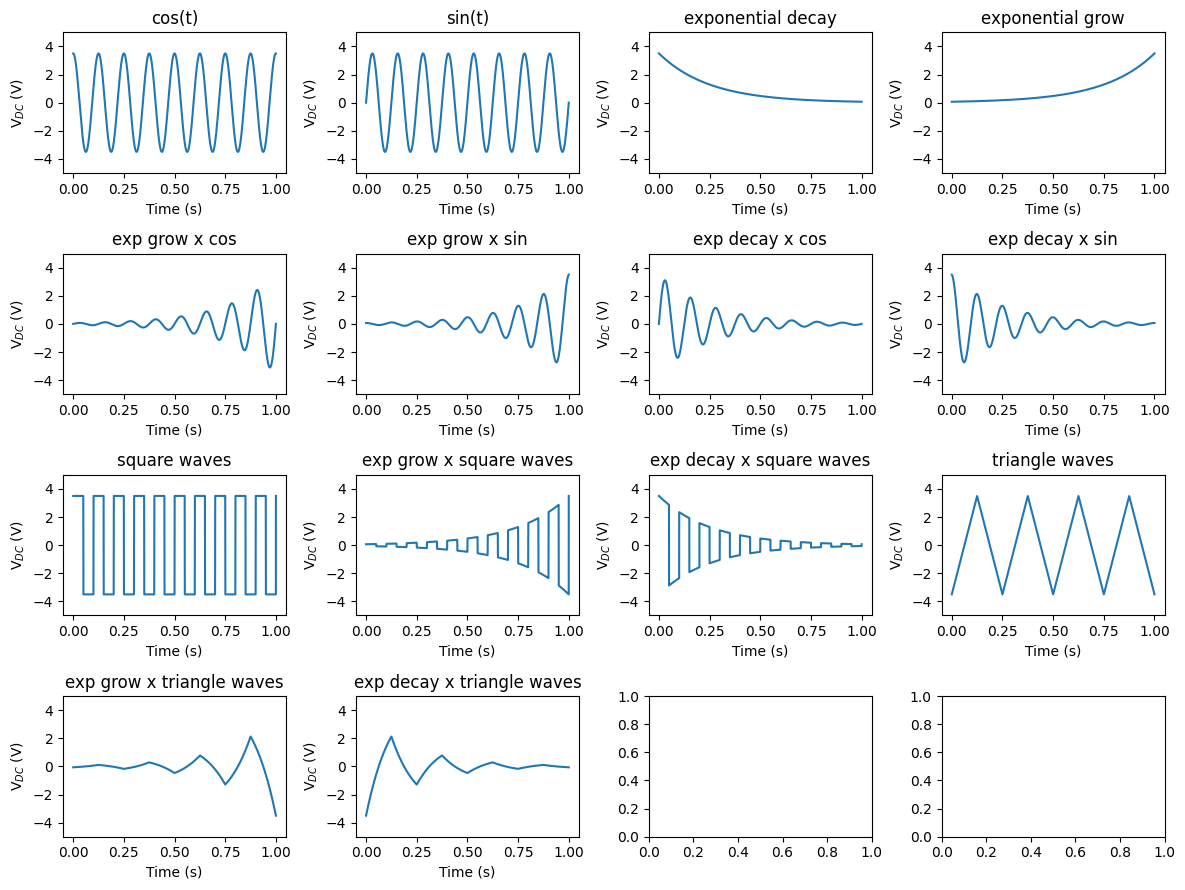

In [5]:
titles = ['cos(t)', 'sin(t)', 'exponential decay', 'exponential grow', 'exp grow x cos', 'exp grow x sin',
          'exp decay x cos', 'exp decay x sin', 'square waves', 'exp grow x square waves', 'exp decay x square waves',
          'triangle waves', 'exp grow x triangle waves', 'exp decay x triangle waves']

fig, ax = plt.subplots(4, 4, figsize=[12, 9])
for i in range(14):
    ax.flatten()[i].plot(t, seedings[i])
    ax.flatten()[i].set_xlabel('Time (s)')
    ax.flatten()[i].set_ylabel('V$_{DC}$ (V)')
    ax.flatten()[i].set_title(titles[i])
    ax.flatten()[i].set_ylim(-5, 5)
plt.tight_layout()

## 5. VAE waveform manifold

A 1D convolutional VAE with a 2D latent space is trained on the 14 seed waveforms. Decoding a 21 x 21 latent grid yields 441 continuously varying candidate waveforms that interpolate between the seed shapes. This grid provides the initial population for the experiment.

In [6]:
"""
Simple unconditional VAE for 4096-point waveforms with 2D latent space.
Includes:
  1) Training code (recon + beta*KL)
  2) Latent visualization:
       - scatter of z_mean colored by property mean (optional)
       - 2D histogram (density) of latent samples
  3) Grid sampling in latent space to generate new waveforms

You provide:
  waveforms_np: (N, 4096) float32/float64
  y_mean_np:    (N,) optional, used only for coloring plots
  y_std_np:     (N,) optional (not used by this simple VAE)
"""

import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt


# ----------------------------
# Utils
# ----------------------------

def set_seed(seed: int = 0):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

@torch.no_grad()
def standardize_waveforms(x: np.ndarray, eps: float = 1e-8):
    """
    Global dataset standardization.
    x: (N, T)
    """
    mu = float(x.mean())
    sd = float(x.std() + eps)
    return (x - mu) / sd, mu, sd


# ----------------------------
# Dataset
# ----------------------------

class WaveformDataset(Dataset):
    def __init__(self, x: torch.Tensor):
        """
        x: (N, T) float32
        """
        assert x.ndim == 2
        self.x = x

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return self.x[idx]


# ----------------------------
# Model: VAE with 2D latent
# ----------------------------

class WaveVAE2D(nn.Module):
    """
    Unconditional VAE for 1D waveforms.
      q(z|x) with z in R^2
      p(x|z)
    """
    def __init__(self, T=4096, z_dim=2, base_ch=16):
        super().__init__()
        self.T = T
        self.z_dim = z_dim

        # Encoder conv stack
        self.enc = nn.Sequential(
            nn.Conv1d(1, base_ch, kernel_size=9, stride=2, padding=4),  # T/2
            nn.GELU(),
            nn.Conv1d(base_ch, base_ch*2, kernel_size=9, stride=2, padding=4),  # T/4
            nn.GELU(),
            nn.Conv1d(base_ch*2, base_ch*4, kernel_size=9, stride=2, padding=4),  # T/8
            nn.GELU(),
            nn.Conv1d(base_ch*4, base_ch*8, kernel_size=9, stride=2, padding=4),  # T/16
            nn.GELU(),
            nn.Conv1d(base_ch*8, base_ch*8, kernel_size=9, stride=2, padding=4),  # T/32
            nn.GELU(),
        )
        enc_len = T // 32
        enc_feat = base_ch * 8 * enc_len

        self.fc_mu = nn.Linear(enc_feat, z_dim)
        self.fc_logvar = nn.Linear(enc_feat, z_dim)

        # Decoder
        self.fc_dec = nn.Linear(z_dim, base_ch * 8 * enc_len)
        self.dec = nn.Sequential(
            nn.ConvTranspose1d(base_ch*8, base_ch*8, kernel_size=9, stride=2, padding=4, output_padding=1),  # *2
            nn.GELU(),
            nn.ConvTranspose1d(base_ch*8, base_ch*4, kernel_size=9, stride=2, padding=4, output_padding=1),  # *4
            nn.GELU(),
            nn.ConvTranspose1d(base_ch*4, base_ch*2, kernel_size=9, stride=2, padding=4, output_padding=1),  # *8
            nn.GELU(),
            nn.ConvTranspose1d(base_ch*2, base_ch, kernel_size=9, stride=2, padding=4, output_padding=1),    # *16
            nn.GELU(),
            nn.ConvTranspose1d(base_ch, 1, kernel_size=9, stride=2, padding=4, output_padding=1),            # *32 -> T
        )

    def encode(self, x):
        """
        x: (B, T) or (B, 1, T)
        returns (mu, logvar)
        """
        if x.ndim == 2:
            x = x.unsqueeze(1)
        h = self.enc(x)              # (B, C, T/32)
        h = h.flatten(1)             # (B, enc_feat)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h).clamp(-10.0, 10.0)
        return mu, logvar

    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        """
        z: (B, 2)
        returns x_hat: (B, T)
        """
        h = self.fc_dec(z)  # (B, C*T/32)
        B = h.shape[0]
        enc_len = self.T // 32
        h = h.view(B, -1, enc_len)  # (B, C, T/32)
        x_hat = self.dec(h).squeeze(1)  # (B, T)
        return x_hat

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar, z


# ----------------------------
# Loss
# ----------------------------

def kl_divergence(mu, logvar):
    # KL(q(z|x)||N(0,1)) per sample, then mean
    return 0.5 * torch.sum(torch.exp(logvar) + mu**2 - 1.0 - logvar, dim=1).mean()


# ----------------------------
# Train
# ----------------------------

def train_vae_2d(
    waveforms_np: np.ndarray,
    epochs: int = 3000,
    batch_size: int = 8,
    lr: float = 2e-4,
    beta_kl: float = 1e-3,
    device: str | None = None,
    seed: int = 0,
):
    """
    Returns:
      model, norm(dict), losses(list)
    """
    set_seed(seed)
    assert waveforms_np.ndim == 2 and waveforms_np.shape[1] == 4096, "Expected (N, 4096)"

    x_n, x_mu, x_sd = standardize_waveforms(waveforms_np.astype(np.float32))
    x = torch.from_numpy(x_n).float()

    ds = WaveformDataset(x)
    dl = DataLoader(ds, batch_size=min(batch_size, len(ds)), shuffle=True, drop_last=False)

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model = WaveVAE2D(T=4096, z_dim=2, base_ch=16).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    losses = []
    model.train()

    for ep in range(1, epochs + 1):
        total = 0.0
        for xb in dl:
            xb = xb.to(device)
            x_hat, mu, logvar, _ = model(xb)

            recon = F.mse_loss(x_hat, xb, reduction="mean")
            kl = kl_divergence(mu, logvar)

            loss = recon + beta_kl * kl

            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()

            total += float(loss.detach().cpu())

        losses.append(total / len(dl))

        if ep % max(1, epochs // 20) == 0 or ep == 1:
            print(f"ep {ep:4d}/{epochs}  loss={losses[-1]:.6f}  recon={float(recon.detach().cpu()):.6f}  beta*KL={beta_kl:.1e}")

    norm = {"x_mu": x_mu, "x_sd": x_sd}
    return model, norm, losses


# ----------------------------
# Latent extraction + plots
# ----------------------------

@torch.no_grad()
def encode_all(model: WaveVAE2D, waveforms_np: np.ndarray, norm: dict, device: str | None = None):
    """
    Returns:
      z_mu: (N, 2)
      z_samp: (N, 2)
    """
    if device is None:
        device = next(model.parameters()).device

    x_n = (waveforms_np.astype(np.float32) - norm["x_mu"]) / norm["x_sd"]
    x = torch.from_numpy(x_n).float().to(device)

    model.eval()
    mu, logvar = model.encode(x)
    z = model.reparam(mu, logvar)
    return mu.detach().cpu().numpy(), z.detach().cpu().numpy()


def plot_latent_scatter(z_mu: np.ndarray, y_mean: np.ndarray | None = None, title: str = "Latent means (z_mu)"):
    plt.figure()
    if y_mean is None:
        plt.scatter(z_mu[:, 0], z_mu[:, 1])
    else:
        sc = plt.scatter(z_mu[:, 0], z_mu[:, 1], c=y_mean, s=60)
        plt.colorbar(sc, label="property mean")
    plt.xlabel("z1")
    plt.ylabel("z2")
    plt.title(title)
    plt.tight_layout()


def plot_latent_density(z_samp: np.ndarray, bins: int = 40, title: str = "Latent sample density (2D histogram)"):
    plt.figure()
    H, xedges, yedges = np.histogram2d(z_samp[:, 0], z_samp[:, 1], bins=bins)
    plt.imshow(
        H.T,
        origin="lower",
        aspect="auto",
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    )
    plt.xlabel("z1")
    plt.ylabel("z2")
    plt.title(title)
    plt.colorbar(label="count")
    plt.tight_layout()


def plot_training_curve(losses):
    plt.figure()
    plt.plot(losses)
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Training loss")
    plt.tight_layout()


# ----------------------------
# Grid-based latent sampling
# ----------------------------

@torch.no_grad()
def decode_grid(
    model: WaveVAE2D,
    norm: dict,
    z1_range=(-3.0, 3.0),
    z2_range=(-3.0, 3.0),
    n1: int = 11,
    n2: int = 11,
    device: str | None = None,
):
    """
    Sample latent points on a 2D grid and decode waveforms.

    Returns:
      Z: (n1*n2, 2) grid coordinates
      X: (n1*n2, 4096) decoded waveforms in ORIGINAL units
    """
    if device is None:
        device = next(model.parameters()).device

    z1 = np.linspace(z1_range[0], z1_range[1], n1, dtype=np.float32)
    z2 = np.linspace(z2_range[0], z2_range[1], n2, dtype=np.float32)
    Z = np.stack(np.meshgrid(z1, z2, indexing="xy"), axis=-1).reshape(-1, 2)  # (n1*n2, 2)

    z = torch.from_numpy(Z).to(device)
    model.eval()
    x_hat_n = model.decode(z)  # standardized
    x_hat = x_hat_n * norm["x_sd"] + norm["x_mu"]
    return Z, x_hat.detach().cpu().numpy()


def plot_some_grid_waveforms(Z: np.ndarray, X: np.ndarray, n_show: int = 9, title: str = "Decoded grid samples"):
    """
    Plots a subset of decoded waveforms and annotates their (z1,z2).
    """
    n_show = min(n_show, X.shape[0])
    idx = np.linspace(0, X.shape[0] - 1, n_show, dtype=int)

    plt.figure()
    for k, i in enumerate(idx):
        plt.plot(X[i], label=f"({Z[i,0]:.2f},{Z[i,1]:.2f})")
    plt.title(title)
    plt.xlabel("t index")
    plt.ylabel("V")
    plt.legend(fontsize=8, ncol=3)
    plt.tight_layout()


import numpy as np
import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def get_latents(model, waveforms_np, norm, device=None):
    """
    Returns:
      z_mu:   (N,2) posterior means
      z_std:  (N,2) posterior stds
      z_samp: (N,2) one sample from q(z|x)
    """
    if device is None:
        device = next(model.parameters()).device

    # standardize waveforms exactly like training
    x_n = (waveforms_np.astype(np.float32) - norm["x_mu"]) / norm["x_sd"]
    x = torch.from_numpy(x_n).float().to(device)

    model.eval()
    mu, logvar = model.encode(x)                 # (N,2), (N,2)
    std = torch.exp(0.5 * logvar)                # (N,2)
    z = mu + std * torch.randn_like(std)         # sample

    return (mu.cpu().numpy(),
            std.cpu().numpy(),
            z.cpu().numpy())

def plot_latent(z_mu, y=None, title="VAE latent (posterior mean)"):
    plt.figure()
    if y is None:
        plt.scatter(z_mu[:,0], z_mu[:,1], s=60)
    else:
        sc = plt.scatter(z_mu[:,0], z_mu[:,1], c=y, s=80)
        plt.colorbar(sc, label="property mean")
    plt.xlabel("z1")
    plt.ylabel("z2")
    plt.title(title)
    plt.tight_layout()

def plot_latent_with_uncertainty(z_mu, z_std, y=None, nsigma=2.0, title="Latent with ±nsigma per-dim"):
    """
    Quick “uncertainty box” visualization: draws a rectangle using z_std in each dim.
    (Not a full covariance ellipse because your encoder outputs diagonal covariance.)
    """
    plt.figure()
    ax = plt.gca()

    if y is None:
        ax.scatter(z_mu[:,0], z_mu[:,1], s=60)
    else:
        sc = ax.scatter(z_mu[:,0], z_mu[:,1], c=y, s=80)
        plt.colorbar(sc, label="property mean")

    # Draw per-point rectangles representing ±nsigma in each dimension
    for i in range(z_mu.shape[0]):
        x0 = z_mu[i,0] - nsigma * z_std[i,0]
        y0 = z_mu[i,1] - nsigma * z_std[i,1]
        w  = 2 * nsigma * z_std[i,0]
        h  = 2 * nsigma * z_std[i,1]
        rect = plt.Rectangle((x0, y0), w, h, fill=False, linewidth=1)
        ax.add_patch(rect)

    plt.xlabel("z1")
    plt.ylabel("z2")
    plt.title(title)
    plt.tight_layout()


import numpy as np
import torch
import matplotlib.pyplot as plt


@torch.no_grad()
def decode_latent_grid(model, norm, z1, z2, device=None):
    """
    Decode a grid defined by arrays z1 (n1,) and z2 (n2,).
    Returns X of shape (n2, n1, T) in ORIGINAL waveform units.
    Note: rows correspond to z2, cols correspond to z1.
    """
    if device is None:
        device = next(model.parameters()).device

    n1 = len(z1)
    n2 = len(z2)

    # Meshgrid: X-axis is z1, Y-axis is z2
    Z1, Z2 = np.meshgrid(z1, z2, indexing="xy")  # (n2, n1)
    Z = np.stack([Z1, Z2], axis=-1).reshape(-1, 2).astype(np.float32)  # (n1*n2, 2)

    z = torch.from_numpy(Z).to(device)
    model.eval()

    x_hat_n = model.decode(z)  # (n1*n2, T), standardized units
    x_hat = x_hat_n * norm["x_sd"] + norm["x_mu"]  # back to original units

    T = x_hat.shape[1]
    X = x_hat.detach().cpu().numpy().reshape(n2, n1, T)
    return X, Z1, Z2


def plot_latent_waveform_panel(
    X, Z1, Z2,
    max_cols=35,
    show_axes=False,
    ylim=None,
    linewidth=0.6,
    title="Decoded waveforms across latent space",
):
    """
    X: (n2, n1, T) waveforms (original units)
    Z1, Z2: (n2, n1) latent coords for annotation if desired
    """
    n2, n1, T = X.shape
    if n1 > max_cols:
        raise ValueError(f"Too many columns ({n1}). Reduce grid or raise max_cols.")

    fig, axes = plt.subplots(n2, n1, figsize=(1.2*n1, 1.0*n2), squeeze=False)

    # Optional consistent y-limits for comparability
    if ylim is None:
        # robust limits across all waveforms
        lo = np.percentile(X, 1)
        hi = np.percentile(X, 99)
        pad = 0.05 * (hi - lo + 1e-9)
        ylim = (lo - pad, hi + pad)

    for r in range(n2):
        for c in range(n1):
            ax = axes[r, c]
            ax.plot(X[r, c], linewidth=linewidth)
            ax.set_ylim(*ylim)

            if not show_axes:
                ax.set_xticks([])
                ax.set_yticks([])
                for sp in ax.spines.values():
                    sp.set_visible(False)

            # light annotation on corners (optional)
            # Uncomment if you want numbers
            # ax.text(0.02, 0.95, f"({Z1[r,c]:.1f},{Z2[r,c]:.1f})",
            #         transform=ax.transAxes, fontsize=6, va="top")

    fig.suptitle(title, y=0.995)
    plt.tight_layout()
    return fig


# --- Optional helper: choose grid range from your encoded data ---
@torch.no_grad()
def latent_range_from_data(model, waveforms_np, norm, q=(5, 95), device=None):
    """
    Encodes all waveforms and returns suggested z1/z2 ranges using percentiles.
    Great for focusing grid on the region your data actually occupies.
    """
    if device is None:
        device = next(model.parameters()).device

    x_n = (waveforms_np.astype(np.float32) - norm["x_mu"]) / norm["x_sd"]
    x = torch.from_numpy(x_n).float().to(device)

    model.eval()
    mu, _ = model.encode(x)  # (N,2)
    z = mu.detach().cpu().numpy()

    z1_lo, z1_hi = np.percentile(z[:, 0], q)
    z2_lo, z2_hi = np.percentile(z[:, 1], q)
    return (float(z1_lo), float(z1_hi)), (float(z2_lo), float(z2_hi))






ep    1/2500  loss=1.005376  recon=1.204123  beta*KL=1.0e-03
ep  125/2500  loss=0.117730  recon=0.096025  beta*KL=1.0e-03
ep  250/2500  loss=0.057880  recon=0.059003  beta*KL=1.0e-03
ep  375/2500  loss=0.032269  recon=0.019476  beta*KL=1.0e-03
ep  500/2500  loss=0.023284  recon=0.012572  beta*KL=1.0e-03
ep  625/2500  loss=0.018717  recon=0.006196  beta*KL=1.0e-03
ep  750/2500  loss=0.015768  recon=0.006793  beta*KL=1.0e-03
ep  875/2500  loss=0.016969  recon=0.008650  beta*KL=1.0e-03
ep 1000/2500  loss=0.013984  recon=0.004665  beta*KL=1.0e-03
ep 1125/2500  loss=0.013155  recon=0.003732  beta*KL=1.0e-03
ep 1250/2500  loss=0.012698  recon=0.004018  beta*KL=1.0e-03
ep 1375/2500  loss=0.011981  recon=0.003764  beta*KL=1.0e-03
ep 1500/2500  loss=0.011711  recon=0.003947  beta*KL=1.0e-03
ep 1625/2500  loss=0.011410  recon=0.003149  beta*KL=1.0e-03
ep 1750/2500  loss=0.010734  recon=0.003806  beta*KL=1.0e-03
ep 1875/2500  loss=0.010660  recon=0.002824  beta*KL=1.0e-03
ep 2000/2500  loss=0.010

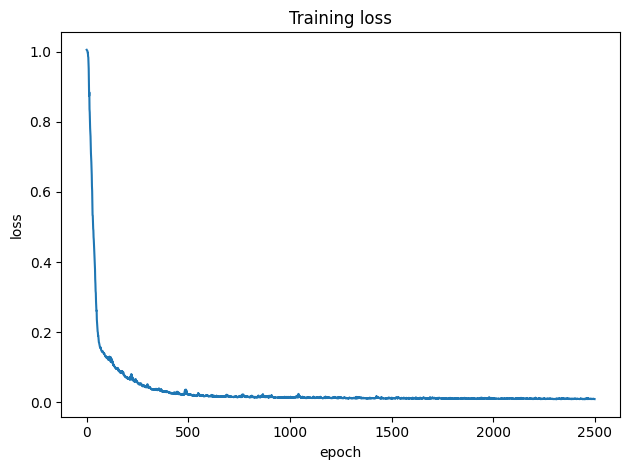

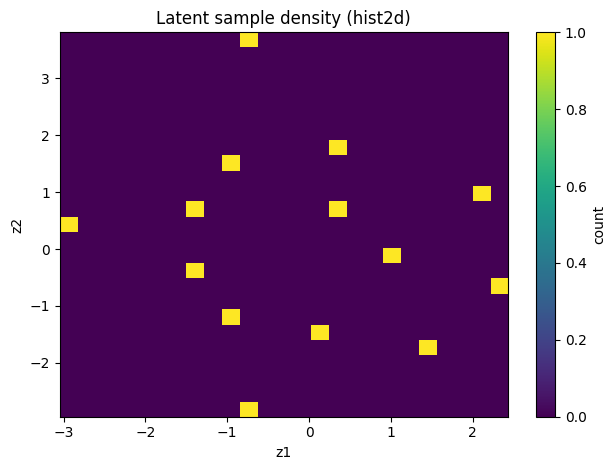

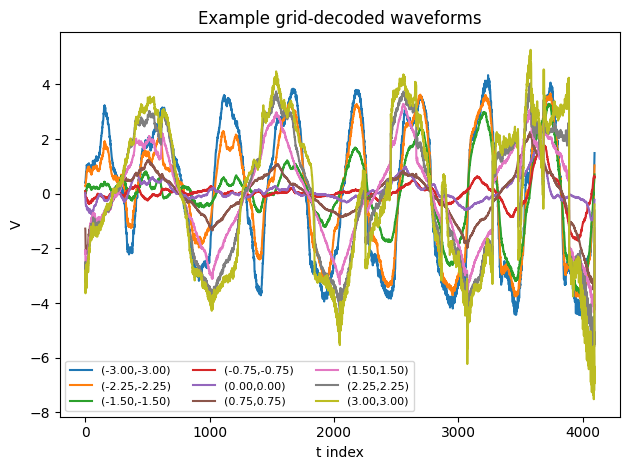

In [7]:
# ----------------------------
# Example usage (replace with your data)
# ----------------------------

if __name__ == "__main__":
    # Replace these with your real arrays:
    # waveforms_np: (14, 4096)
    # y_mean_np: (14,) used only for coloring the latent scatter
    N = 14
    T = 4096
    waveforms_np = np.array(seedings).astype(np.float32)
    
#     y_mean_np = c
#     y_std_np = s

    model, norm, losses = train_vae_2d(
        waveforms_np,
        epochs=2500,
        batch_size=7,
        lr=2e-4,
        beta_kl=1e-3,
        seed=0,
    )

    # Visualize training
    plot_training_curve(losses)

    # Encode and visualize latent
    z_mu, z_samp = encode_all(model, waveforms_np, norm)
#     plot_latent_scatter(z_mu, y_mean=y_mean_np, title="Latent means (colored by property mean)")
    plot_latent_density(z_samp, bins=25, title="Latent sample density (hist2d)")

    # Grid sampling and generation
    Z, Xgen = decode_grid(
        model, norm,
        z1_range=(-3, 3),
        z2_range=(-3, 3),
        n1=9, n2=9,
    )
    print("Grid decoded waveforms:", Xgen.shape)  # (81, 4096)

    # Plot a few generated waveforms
    plot_some_grid_waveforms(Z, Xgen, n_show=9, title="Example grid-decoded waveforms")

    plt.show()


In [8]:
# Decode a 21 x 21 grid in latent space -> X with shape (21, 21, 4096)
z1 = np.linspace(-3, 3, 21)
z2 = np.linspace(-3, 3, 21)

X, Z1, Z2 = decode_latent_grid(model, norm, z1, z2)
plot_latent_waveform_panel(
    X, z1, z2,
    max_panels=21*21,
    figsize=(13, 13),
)

## 6. Instrument interface (requires a live SPM connection)

The microscope is driven through `aespm`. The cells below connect to the instrument, register helper functions on the `Experiment` object, define the measurement grid, and implement the two core measurement primitives:

- `measure_NL(v_ac)`: sweeps the DART drive amplitude and records the tuning curve at each step.
- `evaluate_waveform(waveform, index, v0)`: moves to a fresh grid location, measures ENL, applies the candidate waveform, measures ENL again, and returns the ENL ratio.

Paths and parameters (saving folder, drive frequency, grid spacing) are instrument-specific; adjust them to your setup.

> **Hardware note:** set the DART I Gain to 5 before starting automated measurements, and verify the deflection setpoints (`v0`) after each engage.

In [9]:
import aespm as ae

folder = r"C:\Users\Asylum User\Documents\Asylum Research Data\260410\PZT3"

exp = ae.Experiment(folder=folder)


In [10]:
## Commonly used custom functions

def load_ibw(self, folder="C:\\Users\\Asylum User\\Documents\\AEtesting\\data_exchange", lines=False, header=False, ss=False):
    '''
    Read the latest ibw file saved in a given folder.
    '''
    if folder is None:
        fname = ae.get_files(path=self.folder, client=self.client)[0]
    else:
        fname = ae.get_files(path=folder, client=self.client)[0]
    if header is True:
        return ae.tools.load_ibw(fname, ss=ss)
    else:
        return ae.ibw_read(fname, lines=lines, connection=self.connection)

exp.add_func(load_ibw)

# Function to move the probe with the given displacement
def move_probe(self, r, v0):
    # Move the tip to the center of the scan and start a SS
    time.sleep(1)
    ae.move_tip(r=r, v0=v0, s=self.param['sensitivity'])
    time.sleep(1)
    
exp.add_func(move_probe)

def read_meter(self):
    ae.write_spm(commands="GetMeter()", connection=self.connection)
    w = ae.ibw_read(r"C:\Users\Asylum User\Documents\buffer\Meter.ibw", lines=True, connection=self.connection)
    return w

exp.add_func(read_meter)



# Function to set the deflection
def set_deflection(self, defl=0.5):

    # Zero PD
    self.execute(action='ZeroPD', wait=5)
    self.execute('Stop', wait=1)
    
    defl_read = self.read_meter()[1]

    if defl_read+defl < 0.5:
        defl_set = 0.5
    else:
        defl_set = defl_read+defl
        
    dart_init2 = [
        ['SetpointDefl', defl_set, None],
        ['DARTTrigger', defl_set, None],
    ]

    self.execute_sequence(operation=dart_init2)

exp.add_func(set_deflection)

# Function to move the stage with the given displacement
def stage(self, distance, reset=True):

    # Enable the stage move --> 5 sec, 8 seconds for safety
    self.execute('EnableStage', wait=8)
    ae.move_stage(distance=distance)
    time.sleep(2* 2)
#     self.execute('DisableStage', wait=1)
    # Approaching to the sample surface --> 20 sec, let's use 30 seconds for safety
    
    if reset:
        # Set the new deflection
        self.execute(action='set_deflection', value=0.5)
    
    self.execute('StartApproach', wait=60)
    
    if reset:
        # Set the new deflection
        self.execute(action='set_deflection', value=0.5)
        
exp.add_func(stage)

# Function to check the file number in a given folder
def check_files(self, wait_max = 150):
    return ae.check_file_number(path=self.folder, wait=0.1, retry=int(wait_max/0.1))
exp.add_func(check_files)

def apply_waveform(self, waveform, name=None, tune=False, out=True):
    # Create a 1D NumPy array
    data1 = waveform
    # Create an IgorWave object
    wave = IgorWave(data1, name='MyWave')
    # Save to an .ibw file
    wave.save(r"C:\Users\Asylum User\Documents\buffer\waves.ibw")
    
    self.execute("ChangeFunction")
    self.execute('IVAmpDART', 1, wait=2)
    self.execute('IVFreqDART', 0.25, wait=2)
    self.execute('Cycles', 1, wait=2)
    
    if name is not None:
        self.execute('ChangeName', name)
    if tune is not False:
        w = ae.tune_probe(num=2,path=r"C:\Users\Asylum User\Documents\buffer\Tune.ibw",
                      out=True, center=420e3, width=100e3)
    self.execute('SingleForce', wait=2)
    self.check_files(wait_max=30)
#     time.sleep(2)
#     self.execute('Stop')
    time.sleep(4)
    
    if out is True: 
        spec = self.load_ibw(folder=self.folder, ss=True)
        return spec

exp.add_func(apply_waveform)

t = np.linspace(0, 1, 1024*1)

def func(x):
    return np.where(
        x < 0.5,
        0.1 + 1.2 / 0.5 * x,
        0.1 - 1.2 / 0.5 * (x - 1)
    )

wave_readout = func(t)
wave_readout = np.concatenate([wave_readout,wave_readout,wave_readout,wave_readout])
plt.plot( wave_readout)

In [11]:
# let's read some useful parameters first

xsens, ysens= ae.read_spm(key=['XLVDTSens', 'YLVDTSens'])
exp.update_param('sensitivity', value=[xsens, ysens])

exp.param['sensitivity']


In [12]:
# Function to convert and rotate the pixels to coordinates
def convert_coord(self, data, coord):

    x, y = coord
    
    scan_angle = data.header['ScanAngle']
    
    img = data.data[3] # This is the height channel
    
    # Convert angle to radians
    theta_rad = np.radians(-scan_angle)
    
    # Create 2D rotation matrix
    rot_matrix = np.array([[np.cos(theta_rad), -np.sin(theta_rad)],
                           [np.sin(theta_rad), np.cos(theta_rad)]])
    
    # Apply the rotation matrix to the coordinates
    center = (np.array(np.shape(img))-1) // 2
    x_rot, y_rot = np.zeros_like(x), np.zeros_like(y)
    for i in range(len(x)):
        x_rot[i], y_rot[i] = np.dot(rot_matrix, (np.array([x[i], y[i]])-center)) + center
    
    # Convert the pixels to the distance
    xpixels, ypixels = data.header['PointsLines'],data.header['ScanPoints']
    xsize, ysize = data.header['FastScanSize'],data.header['SlowScanSize']

    xfactor = xsize / xpixels
    yfactor = ysize / ypixels

    positions = np.zeros([len(x), 2])

    for i in range(len(x)):
        positions[i] = np.array([x_rot[i] * xfactor, y_rot[i] * yfactor])

    # Sort the positions according to x first and y second
    pos_sorted = sorted(positions, key=lambda x: (x[1], x[0]))
    
    p = {
        'ScanAngle': scan_angle,
        'xpixels': xpixels,
        'ypixels': ypixels,
        'xsize': xsize,
        'ysize': ysize,
        'xfactor': xfactor,
        'yfactor': yfactor,
    }
    
    for key in p:
        self.update_param(key=key, value=p[key])
    
    return pos_sorted
exp.add_func(convert_coord)

In [13]:
def corrected_measure_pos(self, x, y):

    scan_angle = self.param['header']['ScanAngle']

    # Convert angle to radians
    theta_rad = np.radians(-scan_angle)
    # Create 2D rotation matrix
    rot_matrix = np.array([[np.cos(theta_rad), -np.sin(theta_rad)],
                          [np.sin(theta_rad), np.cos(theta_rad)]])
    center = (np.array(np.shape(self.param['topo']))-1) // 2

    x_rot, y_rot = np.dot(rot_matrix, (np.array([x, y])-center)) + center


    # We need to transfer all the locations to the absolute (0-degree) coordinate
    # Convert the x y pixels into x y positions

    xpixels, ypixels = self.param['header']['PointsLines'],self.param['header']['ScanPoints']
    xsize, ysize = self.param['header']['FastScanSize'],self.param['header']['SlowScanSize']

    xfactor = xsize / xpixels
    yfactor = ysize / ypixels

    return x_rot * xfactor, y_rot * yfactor

exp.add_func(corrected_measure_pos)

### Measurement grid

Candidate waveforms are evaluated on a grid of previously unmeasured locations so that each measurement starts from a fresh aging state.

In [14]:
tx = np.linspace(0, 25, 50) * -1e-6
ty = np.linspace(0, 25, 50) * -1e-6

coords = []

for i in range(len(tx)):
    for j in range(len(ty)):
        coords.append([tx[i], ty[j]])
        
coords = np.array(coords)

In [15]:
# Engage and store the deflection / amplitude setpoints used to detect tip drift
v0 = None
pos_center = np.array([1e-6/2, 1e-6/2])
exp.execute_sequence([
    ['ClearForce', None, None],
    ['GoThere',    None, 1]
])
v0 = ae.read_spm(key=['PIDSLoop.0.Setpoint', 'PIDSLoop.1.Setpoint'])

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- Lorentzian model ---
def lorentz(x, amp, center, width, offset):
    return amp / (1 + ((x - center) / width)**2) + offset

# --- Initial guess ---
p0 = [10e-3, 360e3, 5e3, 1e-4]  # amp, center, width

In [17]:
v_ac = np.array([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2])

freq_center = 365e3

exp.update_param('freq_center', freq_center)

import time

def measure_NL(v_ac, save=None):
    
    N = len(v_ac)

    tunes = []
    params_fit = np.zeros([N, 4])
    
    for i in range(N):
        exp.execute('DriveAmp', v_ac[i])
        w = ae.tune_probe(num=1,path=r"C:\Users\Asylum User\Documents\buffer\Tune.ibw",
                          out=True, center=exp.param['freq_center'], width=50e3, readonly=True)

        time.sleep(1)
        
        tunes.append(w)
        
        p0 = [10e-3, 360e3, 5e3, 1e-4]  # amp, center, width
    
        # --- Fit ---
        try:
            popt, pcov = curve_fit(lorentz, w[0], w[1], p0=p0)
            params_fit[i] = popt
        except:
            params_fit[i] = np.zeros(4)
    exp.execute('DriveAmp', 0.2)
    exp.execute('Stop')
    if save is not None:
        np.savez('{}'.format(save), v_ac=v_ac, tunes=tunes, params=params_fit,)
    return params_fit


In [18]:

# =========================================================
# Example: Replace this with your experiment call
# =========================================================
def evaluate_waveform(waveform_4096, index, v0, repeat=None):

    values = []
    
    pos0 = np.array([1e-6, 1e-6])
    
    # coord = coords[int(index % (50*50))] - np.array([1e-6, 1e-6])
    if index:
        coord = coords[int(index % (50*50))] - coords[int((index-1) % (50*50))]
    else:
        coord = coords[int(index % (50*50))] - pos0
        
    # exp.execute_sequence([
    #     ['ClearForce', None, None],
    #     ['GoThere',    None, 1]
    # ])

    v0 = ae.read_spm(key=['PIDSLoop.0.Setpoint', 'PIDSLoop.1.Setpoint'])
    
    exp.move_probe(r=coord, v0=v0, )
    
    # params_fit = measure_NL(v_ac, save=os.path.join('data', '260410_2', 'before_{:04d}.npz'.format(index)))
    # a1 = compute_nl(v_ac, params_fit[:, 0]*1e3)

    # Apply pulse
    # exp.execute('ApplyToDefaultBias')
    exp.apply_waveform(waveform_4096, name='PZT_write_', out=False)

    exp.execute('Stop', wait=2)

    params_fit = measure_NL(v_ac, save=os.path.join('data', '260410_3', 'after_{:04d}.npz'.format(index)))
    a2 = compute_nl(v_ac, params_fit[:, 0]*1e3)

    return np.abs(a2), index + 1


## 7. DKL surrogate model

A 1D CNN (four conv layers, kernel 9, stride 2, GELU) maps each 4,096-point waveform to a 32-dimensional latent descriptor; an exact GP with a constant mean and an ARD kernel models the ENL ratio on top of these features. The CNN and GP are trained jointly on all waveform-response pairs accumulated so far.

In [19]:
import numpy as np
import torch
import torch.nn as nn
import gpytorch

# -----------------------------
# 1D CNN feature extractor
# -----------------------------
class WaveCNN(nn.Module):
    def __init__(self, feat_dim=32):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=9, stride=2, padding=4), nn.GELU(),
            nn.Conv1d(16, 32, kernel_size=9, stride=2, padding=4), nn.GELU(),
            nn.Conv1d(32, 64, kernel_size=9, stride=2, padding=4), nn.GELU(),
            nn.Conv1d(64, 64, kernel_size=9, stride=2, padding=4), nn.GELU(),
            nn.AdaptiveAvgPool1d(1),  # (B,64,1)
        )
        self.head = nn.Sequential(
            nn.Linear(64, 128), nn.GELU(),
            nn.Linear(128, feat_dim),
        )

    def forward(self, x):          # x: (B,T)
        x = x.unsqueeze(1)         # (B,1,T)
        h = self.conv(x).squeeze(-1)  # (B,64)
        z = self.head(h)           # (B,feat_dim)
        return z


# -----------------------------
# DKL Exact GP
# -----------------------------
class DKLExactGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, feature_extractor, feat_dim):
        super().__init__(train_x, train_y, likelihood)
        self.feature_extractor = feature_extractor
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=feat_dim)
        )

    def forward(self, x):
        z = self.feature_extractor(x)
        mean_x = self.mean_module(z)
        covar_x = self.covar_module(z)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


# -----------------------------
# Utility: standardize (global)
# -----------------------------
def standardize_global(X, eps=1e-6):
    """
    X: (N,T) waveform array
    Returns Xn and (mu, sd) scalars.
    """
    mu = float(X.mean())
    sd = float(X.std())
    sd = max(sd, eps)
    return (X - mu) / sd, mu, sd


def standardize_y(y, eps=1e-6):
    mu = float(y.mean())
    sd = float(y.std())
    sd = max(sd, eps)
    return (y - mu) / sd, mu, sd


# -----------------------------
# Train initial DKL
# -----------------------------
def train_initial_dkl_from_seed(
    wave_pop, y_pop,
    feat_dim=32,
    iters=300,
    lr=1e-2,
    device=None,
    use_fixed_noise=False,
    y_std=None,          # optional: (N,) measurement std if you have it
):
    """
    wave_pop: (N,4096) numpy
    y_pop:    (N,) numpy
    """
    assert wave_pop.ndim == 2 and y_pop.ndim == 1
    assert wave_pop.shape[0] == y_pop.shape[0]

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # --- normalize inputs/targets (recommended)
    wave_n, x_mu, x_sd = standardize_global(wave_pop.astype(np.float32))
    y_n, y_mu, y_sd = standardize_y(y_pop.astype(np.float32))

    X_t = torch.tensor(wave_n, dtype=torch.float32, device=device)
    y_t = torch.tensor(y_n, dtype=torch.float32, device=device)

    # Likelihood
    if use_fixed_noise:
        assert y_std is not None, "Provide y_std if use_fixed_noise=True"
        y_std = np.asarray(y_std, dtype=np.float32)
        y_std_n = y_std / y_sd
        noise = torch.tensor(np.clip(y_std_n**2, 1e-8, None), device=device)
        likelihood = gpytorch.likelihoods.FixedNoiseGaussianLikelihood(noise=noise).to(device)
        learn_noise_params = []  # FixedNoise has no learnable noise
    else:
        likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
        learn_noise_params = [{"params": likelihood.parameters(), "lr": lr}]

    feature_extractor = WaveCNN(feat_dim=feat_dim).to(device)
    model = DKLExactGP(X_t, y_t, likelihood, feature_extractor, feat_dim=feat_dim).to(device)

    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam(
        [
            {"params": model.feature_extractor.parameters(), "lr": lr},
            {"params": model.mean_module.parameters(), "lr": lr},
            {"params": model.covar_module.parameters(), "lr": lr},
            *learn_noise_params,
        ]
    )

    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for i in range(1, iters + 1):
        optimizer.zero_grad(set_to_none=True)
        output = model(X_t)
        loss = -mll(output, y_t)
        loss.backward()
        optimizer.step()

        if i % 50 == 0 or i == 1:
            if hasattr(likelihood, "noise"):
                noise_val = float(likelihood.noise.detach().cpu())
            else:
                noise_val = float("nan")
            print(f"iter {i:4d}/{iters}  loss={loss.item():.4f}  noise={noise_val:.3e}")

    pack = {
        "model": model,
        "likelihood": likelihood,
        "device": device,
        "norm": {
            "x_mu": x_mu, "x_sd": x_sd,
            "y_mu": y_mu, "y_sd": y_sd,
        }
    }
    return pack


@torch.no_grad()
def dkl_predict(pack, wave_query):
    """
    wave_query: (M,4096) or (4096,) numpy
    Returns mu, std in ORIGINAL y units.
    """
    model = pack["model"]
    likelihood = pack["likelihood"]
    device = pack["device"]
    norm = pack["norm"]

    w = np.asarray(wave_query, dtype=np.float32)
    if w.ndim == 1:
        w = w[None, :]
    w_n = (w - norm["x_mu"]) / norm["x_sd"]

    Xq = torch.tensor(w_n, dtype=torch.float32, device=device)

    model.eval(); likelihood.eval()
    with gpytorch.settings.fast_pred_var():
        pred = likelihood(model(Xq))
        mu_n = pred.mean.detach().cpu().numpy()
        std_n = pred.variance.clamp_min(1e-12).sqrt().detach().cpu().numpy()

    mu = mu_n * norm["y_sd"] + norm["y_mu"]
    std = std_n * norm["y_sd"]
    return mu, std


## 8. GA candidate generation

The GA operates on the Fourier genotype theta = [dc, a1..a16, b1..b16] (33 parameters). Parents are chosen by tournament selection from the best measured waveforms; offspring are produced by BLX-alpha blend crossover (alpha = 0.5) and additive Gaussian mutation (sigma = 0.15, p_mut = 0.7), then clipped to bounds and synthesized into waveforms with |V(t)| <= vmax. Each generation produces a pool of ~1,000 unique candidates.

In [20]:
import numpy as np

# -----------------------------
# Helpers: GA ops in theta-space
# -----------------------------
def tournament_select(pop, fitness, k=3, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    idx = rng.choice(len(pop), size=k, replace=False)
    return pop[idx[np.argmax(fitness[idx])]].copy()

def blx_alpha_crossover(p1, p2, alpha=0.5, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    lo = np.minimum(p1, p2) - alpha * np.abs(p1 - p2)
    hi = np.maximum(p1, p2) + alpha * np.abs(p1 - p2)
    return rng.uniform(lo, hi).astype(np.float32)

def mutate(theta, sigma=0.15, p_mut=0.7, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    if rng.random() < p_mut:
        theta = theta + rng.normal(0.0, sigma, size=theta.shape).astype(np.float32)
    return theta.astype(np.float32)

def unique_rows(arr, decimals=6):
    # de-dup by rounding
    rounded = np.round(arr, decimals=decimals)
    _, idx = np.unique(rounded, axis=0, return_index=True)
    return arr[np.sort(idx)]

# -----------------------------
# Convert theta batch -> safe wave batch
# -----------------------------
def theta_to_safe_waves(theta_batch, fourier_synthesis, enforce_slew,
                        clip_theta, bounds, T=4096, vmax=3.5, max_slew=None):
    X = []
    for th in theta_batch:
        th = clip_theta(th, bounds)
        x = fourier_synthesis(th, T=T)
        x = enforce_slew(x, max_slew=max_slew, vmax=vmax)
        X.append(x.astype(np.float32))
    return np.stack(X, axis=0).astype(np.float32)

# -----------------------------
# Main: generate 1000 candidates
# -----------------------------
def ga_generate_candidates_1000(
    # seeds
    wave_measured_64,                 # (64,4096) measured waveforms
    # optional extra seeds
    wave_vae=None,                    # (Nvae,4096) optional VAE waveforms
    use_vae=True,
    # parameterization
    K=16, T=4096,
    fourier_fit=None,
    fourier_synthesis=None,
    # constraints
    enforce_slew=None,
    vmax=3.5,
    max_slew=None,
    bounds=None,
    theta_bounds=None,
    clip_theta=None,
    # surrogate
    predict_mu_std=None,              # function(waves: (M,4096)) -> (mu:(M,), std:(M,))
    kappa=2.0,
    # GA config
    pop_size=128,
    generations=30,
    elite_frac=0.15,
    alpha=0.5,
    mut_sigma=0.15,
    mut_p=0.7,
    # candidate output
    n_candidates=1000,
    # randomness
    rng_seed=0
):
    """
    Returns:
      cand_theta: (n_candidates, D)
      cand_wave:  (n_candidates, 4096)
      cand_ucb:   (n_candidates,)
    """
    assert fourier_fit is not None and fourier_synthesis is not None
    assert enforce_slew is not None
    assert predict_mu_std is not None
    assert theta_bounds is not None and clip_theta is not None

    rng = np.random.default_rng(rng_seed)

    # --- bounds
    if bounds is None:
        bounds = theta_bounds(K=K, dc_bound=vmax, harm_bound=2.0)

    D = 1 + 2 * K

    # --- build initial theta seeds from measured (and VAE)
    Theta_seed = []
    for x in wave_measured_64:
        th = fourier_fit(x, K=K)
        th = clip_theta(th, bounds)
        Theta_seed.append(th)

    if use_vae and (wave_vae is not None) and (len(wave_vae) > 0):
        for x in wave_vae:
            # important: enforce constraints before fitting theta
            x2 = enforce_slew(x, max_slew=max_slew, vmax=vmax)
            th = fourier_fit(x2, K=K)
            th = clip_theta(th, bounds)
            Theta_seed.append(th)

    Theta_seed = np.stack(Theta_seed, axis=0).astype(np.float32)
    Theta_seed = unique_rows(Theta_seed, decimals=6)

    # --- top-up random if needed
    def sample_random_theta(n):
        lo = bounds[:, 0]
        hi = bounds[:, 1]
        return rng.uniform(lo, hi, size=(n, D)).astype(np.float32)

    if Theta_seed.shape[0] >= pop_size:
        pop = Theta_seed[:pop_size].copy()
    else:
        extra = sample_random_theta(pop_size - Theta_seed.shape[0])
        pop = np.vstack([Theta_seed, extra]).astype(np.float32)

    pop = np.stack([clip_theta(p, bounds) for p in pop], axis=0).astype(np.float32)

    # --- archive for unique candidates (store theta + ucb)
    cand_theta = []
    cand_ucb = []
    seen = set()

    def add_to_archive(theta_batch, ucb_batch):
        for th, u in zip(theta_batch, ucb_batch):
            key = tuple(np.round(th, 6))
            if key in seen:
                continue
            seen.add(key)
            cand_theta.append(th.copy())
            cand_ucb.append(float(u))

    # --- GA loop
    elite_n = max(1, int(round(elite_frac * pop_size)))

    for gen in range(generations):
        # Evaluate current population by surrogate UCB on waveform phenotype
        pop_waves = theta_to_safe_waves(
            pop, fourier_synthesis, enforce_slew,
            clip_theta, bounds, T=T, vmax=vmax, max_slew=max_slew
        )

        mu, std = predict_mu_std(pop_waves)  # arrays (pop_size,)
        ucb = mu + kappa * std

        add_to_archive(pop, ucb)

        # Stop if enough collected
        if len(cand_theta) >= n_candidates:
            break

        # Elitism
        order = np.argsort(ucb)[::-1]
        elites = pop[order[:elite_n]].copy()

        # Make offspring
        offspring = []
        while len(offspring) < (pop_size - elite_n):
            p1 = tournament_select(pop, ucb, k=3, rng=rng)
            p2 = tournament_select(pop, ucb, k=3, rng=rng)
            c = blx_alpha_crossover(p1, p2, alpha=alpha, rng=rng)
            c = mutate(c, sigma=mut_sigma, p_mut=mut_p, rng=rng)
            c = clip_theta(c, bounds)
            offspring.append(c)

        pop = np.vstack([elites, np.array(offspring, dtype=np.float32)]).astype(np.float32)

        # mild diversity injection (optional): replace worst few with random
        if pop_size >= 20:
            n_inject = max(1, pop_size // 20)
            pop[-n_inject:] = sample_random_theta(n_inject)

        pop = unique_rows(pop, decimals=6)
        # if dedup shrank pop, top up
        if pop.shape[0] < pop_size:
            pop = np.vstack([pop, sample_random_theta(pop_size - pop.shape[0])]).astype(np.float32)

        print(f"[gen {gen:02d}] archive={len(cand_theta)}  best_ucb={ucb.max():.4g}")

    # --- pick top n_candidates by UCB and synthesize waveforms
    cand_theta = np.array(cand_theta, dtype=np.float32)
    cand_ucb = np.array(cand_ucb, dtype=np.float32)

    if cand_theta.shape[0] == 0:
        raise RuntimeError("GA produced no candidates. Check predict_mu_std or seeds.")

    top = np.argsort(cand_ucb)[::-1][:n_candidates]
    cand_theta = cand_theta[top]
    cand_ucb = cand_ucb[top]

    cand_wave = theta_to_safe_waves(
        cand_theta, fourier_synthesis, enforce_slew,
        clip_theta, bounds, T=T, vmax=vmax, max_slew=max_slew
    )

    return cand_theta, cand_wave, cand_ucb


In [21]:
# Wrapper exposing the trained DKL pack to the GA as a mu/std predictor
def predict_mu_std_from_pack(waves_batch):
    mu, std = dkl_predict(pack, waves_batch)  # returns in original y units
    return mu.reshape(-1), std.reshape(-1)

## 9. Candidate ranking and batch selection

The DKL surrogate scores every candidate with an upper confidence bound, UCB = mu + kappa*sigma (kappa = 2). Already-measured waveforms are filtered out, and an optional greedy diversity filter enforces a minimum L2 separation between selected waveforms.

In [22]:
import numpy as np

def compute_ucb_for_candidates(pack, cand_wave, kappa=2.0, batch_size=256):
    """
    cand_wave: (N,4096)
    returns mu, std, ucb: each (N,)
    """
    N = cand_wave.shape[0]
    mu_all = np.zeros(N, dtype=np.float32)
    std_all = np.zeros(N, dtype=np.float32)

    for s in range(0, N, batch_size):
        e = min(N, s + batch_size)
        mu, std = dkl_predict(pack, cand_wave[s:e])  # mu,std are (B,) or (B,1)
        mu_all[s:e] = np.asarray(mu).reshape(-1)
        std_all[s:e] = np.asarray(std).reshape(-1)

    ucb = mu_all + kappa * std_all
    return mu_all, std_all, ucb

def wave_key(x, stride=16, decimals=3):
    # subsample and round -> hashable tuple
    return tuple(np.round(x[::stride], decimals=decimals))

def filter_out_seen(cand_wave, cand_scores, seen_waveforms=None, stride=16, decimals=3):
    """
    Removes candidates whose waveform key matches any in seen_waveforms.
    """
    seen = set()
    if seen_waveforms is not None:
        for x in seen_waveforms:
            seen.add(wave_key(x, stride=stride, decimals=decimals))

    keep_idx = []
    for i, x in enumerate(cand_wave):
        k = wave_key(x, stride=stride, decimals=decimals)
        if k in seen:
            continue
        keep_idx.append(i)
        seen.add(k)  # also avoid duplicates within candidates

    keep_idx = np.array(keep_idx, dtype=int)
    return keep_idx


In [23]:
def select_topk_diverse(waves, score, k=16, min_l2=5.0, stride=8):
    """
    Greedy selection: high score + diversity in waveform space.
    min_l2 is computed on downsampled waveforms (stride).
    """
    order = np.argsort(score)[::-1]
    chosen = []
    chosen_ds = []

    for idx in order:
        x = waves[idx]
        x_ds = x[::stride].astype(np.float32)

        ok = True
        for y_ds in chosen_ds:
            if np.linalg.norm(x_ds - y_ds) < min_l2:
                ok = False
                break

        if ok:
            chosen.append(idx)
            chosen_ds.append(x_ds)

        if len(chosen) >= k:
            break

    # fallback if too strict
    if len(chosen) < k:
        for idx in order:
            if idx not in chosen:
                chosen.append(idx)
            if len(chosen) >= k:
                break

    return np.array(chosen, dtype=int)


In [24]:
def choose_next_batch_64(pack, cand_wave, wave_measured=None, kappa=2.0,
                         batch_size=256, k=64,
                         dedup_stride=16, dedup_decimals=3,
                         diverse=True, diverse_stride=8, diverse_min_l2=5.0):

    mu, std, ucb = compute_ucb_for_candidates(pack, cand_wave, kappa=kappa, batch_size=batch_size)

    keep_idx = filter_out_seen(cand_wave, ucb, seen_waveforms=wave_measured,
                               stride=dedup_stride, decimals=dedup_decimals)

    cw = cand_wave[keep_idx]
    mu = mu[keep_idx]; std = std[keep_idx]; ucb = ucb[keep_idx]

    if cw.shape[0] < k:
        raise RuntimeError(f"Only {cw.shape[0]} unique candidates remain after de-dup; need {k}.")

    if diverse:
        sel = select_topk_diverse(cw, ucb, k=k, min_l2=diverse_min_l2, stride=diverse_stride)
    else:
        sel = np.argsort(ucb)[::-1][:k]

    return {
        "next_waveforms": cw[sel],
        "next_mu": mu[sel],
        "next_std": std[sel],
        "next_ucb": ucb[sel],
        "selected_indices_in_cand": keep_idx[sel],
        "all_mu": mu, "all_std": std, "all_ucb": ucb, "keep_idx": keep_idx
    }


## 10. Initial seeding experiment (requires instrument)

64 waveforms are drawn at random from the 21 x 21 VAE grid, slew-checked, and measured to build the initial training set.

In [25]:
K=16
pop_size=48
vmax=3
evals_per_gen=8
seed_size=64


In [26]:
indices = np.random.randint(0, 21**2, size=64)

wave_pop = np.zeros([64, 4096])

for i in range(64):
    index = indices[i]
    wave_pop[i] = enforce_slew((X[index//21, index%21]), max_slew=None, vmax=vmax)
    

In [27]:
# Measure the ENL ratio for all 64 seed waveforms
idx = 0
y_pop = np.zeros(64)

for i in range(64):
    y_pop[i], idx = evaluate_waveform(wave_pop[i], idx, v0=v0)

The saved per-location files can be reloaded to recompute the seed responses offline:

In [28]:
folder = os.path.join('data', '260410_3')

fnames = os.listdir(folder)

data_test = []

for f in fnames:
    if f.startswith('after'):
        data_test.append(np.load(os.path.join(folder, f)))

In [29]:
N = len(data_test)

y_test = np.zeros(N)

for i in range(N):
    tp = data_test[i]
    v_fit = tp['v_ac'][:-2]
    amp_fit = tp['params'][:-2,0] * 1e3

    y_test[i] = compute_nl(v_fit, amp_fit)

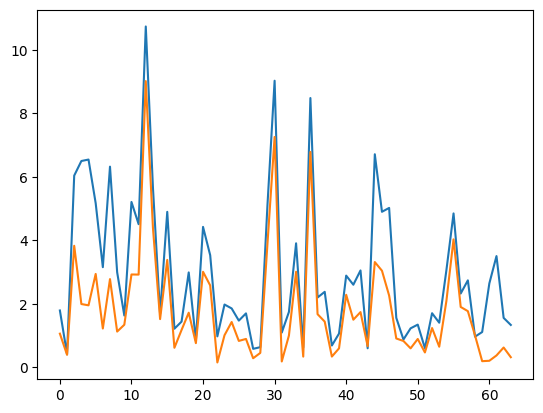

In [30]:
plt.plot(y_pop, label='online')
plt.plot(y_test, label='recomputed offline')
plt.xlabel('Seed waveform index')
plt.ylabel('ENL ratio')
plt.legend()

## 11. GA-DKL active-learning loop (requires instrument)

Each iteration: (i) retrain the DKL on all measured data, (ii) generate ~1,000 GA candidates from the current best waveforms, (iii) rank by UCB and select the next batch, (iv) measure the batch on the instrument, and (v) append the results to the archive. The campaign in the paper ran 40 generations with 32 evaluations per generation.

In [31]:
y_measured_temp = np.copy(y_pop)
x_measured_temp = np.copy(wave_pop)
next_64 = np.copy(wave_pop)
N_eval = 32
vmax = 3

T = 4096

for iteration in range(40):
    print('Working on {}/{}'.format(iteration, 40))
    # re-train the DKL model
    pack = train_initial_dkl_from_seed(
        wave_pop=x_measured_temp,
        y_pop=y_measured_temp,
        feat_dim=32,
        iters=250,
        lr=1e-2,
        device=None,      # auto
        use_fixed_noise=False
    )
    
    # Generate the new 1,000 candidates
    cand_theta, cand_wave, cand_ucb = ga_generate_candidates_1000(
        wave_measured_64=next_64,   # (64,4096)
        wave_vae=None,                # optional (Nvae,4096) or None
        use_vae=False,

        K=16, T=4096,
        fourier_fit=fourier_fit,
        fourier_synthesis=fourier_synthesis,

        enforce_slew=enforce_slew,
        vmax=vmax, max_slew=None,

        bounds=None,
        theta_bounds=theta_bounds,
        clip_theta=clip_theta,

        predict_mu_std=predict_mu_std_from_pack,
        kappa=2.0,

        pop_size=128,
        generations=40,

        n_candidates=1000,
        rng_seed=0
    )

    # compute UCB for these 1,000 new waves
    # then select the top 64 candidates
    out = choose_next_batch_64(
        pack,
        cand_wave=cand_wave,              # (1000,4096)
        wave_measured=None,      # your already-measured 64 (if you have them)
        kappa=2.0,
        diverse=False,
        k=N_eval,
    )

    next_64 = out["next_waveforms"]
    
    # Measure the newly generated 64 waves
    # idx = 100
    y_next = np.zeros(N_eval)
    # exp.execute_sequence([
    #     ['ClearForce', None, None],
    #     ['GoThere',    None, 1]
    # ])
    
    for i in range(N_eval):
        y_next[i], idx = evaluate_waveform(next_64[i], idx, v0=v0)
        
    y_measured_temp = np.concatenate([y_measured_temp, y_next])
    x_measured_temp = np.concatenate([x_measured_temp, next_64])

In [32]:
# Save the full archive of measured waveforms and responses
np.savez('PZT-GA-DKL-results.npz', waves=x_measured_temp, y=y_measured_temp)

## Appendix: self-contained end-to-end script

The cell below contains the complete GA-DKL loop in a single, runnable script with a *synthetic* objective standing in for the instrument (replace `evaluate_waveform` with your hardware call). Useful for testing the optimization machinery offline.

In [33]:
"""
GA–DKL iterative optimization over waveforms (length 4096) with Fourier genotype θ.

What this script does (end-to-end, runnable):
  1) Defines a synthetic "real system" evaluate_waveform(x) -> (y_mean, y_std)
     (replace this with your instrument call).
  2) Initializes 64 measured points by sampling θ, synthesizing safe waveforms, measuring y.
  3) Repeats for R rounds:
       - Train a DKL surrogate: 1D CNN feature extractor + Exact GP on latent features.
       - Run GA in θ-space using surrogate UCB fitness on waveform phenotype.
       - Collect 1000 unique candidate waveforms (excluding already measured).
       - Select a diverse batch of 16 candidates with highest UCB.
       - Measure them, append to archive.

Dependencies:
  pip install numpy torch gpytorch
"""

import math
import numpy as np
import torch
import torch.nn as nn
import gpytorch


# =========================================================
# 0) "Real system" objective (replace with your hardware)
# =========================================================

def evaluate_waveform_synthetic(x, noise_y=0.02, repeat=3, rng=None):
    """
    Synthetic objective that depends on the *full waveform*.
    Returns (y_mean, y_std_of_mean_estimate).

    Replace this function with your hardware call:
        ym, ys = evaluate_waveform(x)
    """
    rng = np.random.default_rng() if rng is None else rng
    x = np.asarray(x, dtype=np.float32)

    # A waveform-dependent target: combine spectral bands + time-domain nonlinearity.
    fft = np.fft.rfft(x)
    mag = np.abs(fft)

    band1 = float(np.mean(mag[2:20]))
    band2 = float(np.mean(mag[40:90]))
    band3 = float(np.mean(mag[150:250]))

    # Add a small time-domain contribution (e.g. smoothness penalty / shape reward)
    dx = np.diff(x)
    rough = float(np.mean(np.abs(dx)))

    # True function (unknown to optimizer)
    y_true = math.tanh(0.7 * band1 - 0.4 * band2 + 0.15 * band3) - 0.05 * rough

    # repeated noisy measurements
    ys = []
    for _ in range(int(repeat)):
        ys.append(y_true + rng.normal(0.0, noise_y))
    ys = np.array(ys, dtype=np.float32)

    y_mean = float(np.mean(ys))
    # std of mean estimate:
    y_std = float(np.std(ys, ddof=1) / max(np.sqrt(len(ys)), 1.0)) if len(ys) > 1 else float(noise_y)
    return y_mean, y_std


# =========================================================
# 1) Fourier synthesis / fit
# =========================================================

def fourier_synthesis(theta, T=4096):
    """
    theta: (D,) where D = 1 + 2K
      theta[0] = dc
      theta[1:1+K] = a_k
      theta[1+K:1+2K] = b_k
    returns x: (T,)
    """
    theta = np.asarray(theta, dtype=np.float32)
    D = theta.shape[0]
    assert (D - 1) % 2 == 0
    K = (D - 1) // 2

    dc = theta[0]
    a = theta[1:1+K]
    b = theta[1+K:1+2*K]

    t = np.linspace(0, 2*np.pi, T, endpoint=False, dtype=np.float32)
    x = np.full((T,), dc, dtype=np.float32)
    for k in range(1, K + 1):
        x += a[k-1] * np.cos(k*t) + b[k-1] * np.sin(k*t)
    return x.astype(np.float32)

def fourier_fit(x, K=16):
    """
    Least-squares fit to get theta from a waveform x.
    """
    x = np.asarray(x, dtype=np.float32)
    T = x.shape[0]
    t = np.linspace(0, 2*np.pi, T, endpoint=False, dtype=np.float32)

    cols = [np.ones_like(t)]
    for k in range(1, K+1):
        cols.append(np.cos(k*t))
    for k in range(1, K+1):
        cols.append(np.sin(k*t))
    A = np.stack(cols, axis=1).astype(np.float32)  # (T, 1+2K)

    theta, *_ = np.linalg.lstsq(A, x, rcond=None)
    return theta.astype(np.float32)


# =========================================================
# 2) Constraints / bounds
# =========================================================

def enforce_vmax_scale(x, vmax=3.5):
    x = np.asarray(x, dtype=np.float32).copy()
    peak = float(np.max(np.abs(x)))
    if peak > vmax and peak > 0:
        x *= (vmax / peak)
    return x.astype(np.float32)

def enforce_slew(x, max_slew=None, vmax=3.5):
    """
    Optional slew constraint (V per sample).
    If max_slew is None: only scale to vmax.
    """
    x = np.asarray(x, dtype=np.float32).copy()
    if max_slew is None:
        return enforce_vmax_scale(x, vmax=vmax)

    dx = np.diff(x, prepend=x[0])
    dx = np.clip(dx, -max_slew, max_slew)
    x = np.cumsum(dx).astype(np.float32)
    return enforce_vmax_scale(x, vmax=vmax)

def theta_bounds(K=16, dc_bound=3.5, harm_bound=2.0):
    D = 1 + 2*K
    b = np.zeros((D, 2), dtype=np.float32)
    b[0] = [-dc_bound, dc_bound]
    b[1:] = [-harm_bound, harm_bound]
    return b

def clip_theta(theta, bounds):
    return np.clip(theta, bounds[:, 0], bounds[:, 1]).astype(np.float32)

def sample_random_theta(n, bounds, rng):
    lo = bounds[:, 0]
    hi = bounds[:, 1]
    return rng.uniform(lo, hi, size=(n, bounds.shape[0])).astype(np.float32)


# =========================================================
# 3) DKL: 1D CNN feature extractor + Exact GP on latent z
# =========================================================

class WaveCNN(nn.Module):
    """
    waveform x: (B,4096) -> latent z: (B,feat_dim)
    """
    def __init__(self, feat_dim=32):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=9, stride=2, padding=4), nn.GELU(),
            nn.Conv1d(16, 32, kernel_size=9, stride=2, padding=4), nn.GELU(),
            nn.Conv1d(32, 64, kernel_size=9, stride=2, padding=4), nn.GELU(),
            nn.Conv1d(64, 64, kernel_size=9, stride=2, padding=4), nn.GELU(),
            nn.AdaptiveAvgPool1d(1),  # (B,64,1)
        )
        self.head = nn.Sequential(
            nn.Linear(64, 128), nn.GELU(),
            nn.Linear(128, feat_dim),
        )

    def forward(self, x):
        x = x.unsqueeze(1)                # (B,1,T)
        h = self.conv(x).squeeze(-1)      # (B,64)
        z = self.head(h)                  # (B,feat_dim)
        return z

class DKLExactGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, feature_extractor, feat_dim):
        super().__init__(train_x, train_y, likelihood)
        self.feature_extractor = feature_extractor
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=feat_dim)
        )

    def forward(self, x):
        z = self.feature_extractor(x)
        mean_x = self.mean_module(z)
        covar_x = self.covar_module(z)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

def _standardize_global(X, eps=1e-6):
    mu = float(X.mean())
    sd = float(X.std())
    sd = max(sd, eps)
    return (X - mu) / sd, mu, sd

def _standardize_y(y, eps=1e-6):
    mu = float(y.mean())
    sd = float(y.std())
    sd = max(sd, eps)
    return (y - mu) / sd, mu, sd

def train_dkl_waveform(X_eval, y_eval, feat_dim=32, iters=200, lr=1e-2, device=None):
    """
    Train DKL on ALL measured data.
    Returns a 'pack' with model, likelihood, and normalization stats.
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    X_eval = np.asarray(X_eval, dtype=np.float32)
    y_eval = np.asarray(y_eval, dtype=np.float32)

    # normalize X and y
    Xn, x_mu, x_sd = _standardize_global(X_eval)
    yn, y_mu, y_sd = _standardize_y(y_eval)

    X_t = torch.tensor(Xn, dtype=torch.float32, device=device)
    y_t = torch.tensor(yn, dtype=torch.float32, device=device)

    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
    feature_extractor = WaveCNN(feat_dim=feat_dim).to(device)
    model = DKLExactGP(X_t, y_t, likelihood, feature_extractor, feat_dim=feat_dim).to(device)

    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam(
        [
            {"params": model.feature_extractor.parameters(), "lr": lr},
            {"params": model.mean_module.parameters(), "lr": lr},
            {"params": model.covar_module.parameters(), "lr": lr},
            {"params": likelihood.parameters(), "lr": lr},
        ]
    )
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for i in range(1, iters + 1):
        optimizer.zero_grad(set_to_none=True)
        out = model(X_t)
        loss = -mll(out, y_t)
        loss.backward()
        optimizer.step()

        if i == 1 or i % 50 == 0:
            noise_val = float(likelihood.noise.detach().cpu())
            print(f"  DKL train iter {i:4d}/{iters}  loss={loss.item():.4f}  noise={noise_val:.3e}")

    pack = {
        "model": model,
        "likelihood": likelihood,
        "device": device,
        "norm": {"x_mu": x_mu, "x_sd": x_sd, "y_mu": y_mu, "y_sd": y_sd},
    }
    return pack

@torch.no_grad()
def dkl_predict(pack, waves, batch_size=256):
    """
    waves: (N,4096) or (4096,)
    Returns mu, std in ORIGINAL y units (numpy arrays shape (N,))
    """
    model = pack["model"]
    likelihood = pack["likelihood"]
    device = pack["device"]
    norm = pack["norm"]

    w = np.asarray(waves, dtype=np.float32)
    if w.ndim == 1:
        w = w[None, :]

    # normalize using training stats
    w_n = (w - norm["x_mu"]) / norm["x_sd"]

    model.eval()
    likelihood.eval()

    N = w_n.shape[0]
    mu_out = np.zeros(N, dtype=np.float32)
    std_out = np.zeros(N, dtype=np.float32)

    with gpytorch.settings.fast_pred_var():
        for s in range(0, N, batch_size):
            e = min(N, s + batch_size)
            Xq = torch.tensor(w_n[s:e], dtype=torch.float32, device=device)
            pred = likelihood(model(Xq))
            mu_n = pred.mean.detach().cpu().numpy().reshape(-1)
            std_n = pred.variance.clamp_min(1e-12).sqrt().detach().cpu().numpy().reshape(-1)

            mu_out[s:e] = mu_n * norm["y_sd"] + norm["y_mu"]
            std_out[s:e] = std_n * norm["y_sd"]

    return mu_out, std_out


# =========================================================
# 4) GA in θ-space using surrogate UCB fitness on waveforms
# =========================================================

def tournament_select(pop, fitness, k=3, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    idx = rng.choice(len(pop), size=k, replace=False)
    return pop[idx[np.argmax(fitness[idx])]].copy()

def blx_alpha_crossover(p1, p2, alpha=0.5, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    lo = np.minimum(p1, p2) - alpha * np.abs(p1 - p2)
    hi = np.maximum(p1, p2) + alpha * np.abs(p1 - p2)
    return rng.uniform(lo, hi).astype(np.float32)

def mutate(theta, sigma=0.15, p_mut=0.7, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    if rng.random() < p_mut:
        theta = theta + rng.normal(0.0, sigma, size=theta.shape).astype(np.float32)
    return theta.astype(np.float32)

def unique_rows(arr, decimals=6):
    rounded = np.round(arr, decimals=decimals)
    _, idx = np.unique(rounded, axis=0, return_index=True)
    return arr[np.sort(idx)]

def theta_to_safe_waves(theta_batch, K, T, bounds, vmax, max_slew):
    X = []
    for th in theta_batch:
        th = clip_theta(th, bounds)
        x = fourier_synthesis(th, T=T)
        x = enforce_slew(x, max_slew=max_slew, vmax=vmax)
        X.append(x.astype(np.float32))
    return np.stack(X, axis=0).astype(np.float32)

def _wave_key(x, stride=16, decimals=3):
    return tuple(np.round(x[::stride], decimals=decimals))

def ga_generate_candidates(
    pack,
    X_measured,                 # (N_measured,4096)
    K=16, T=4096,
    vmax=3.5, max_slew=None,
    bounds=None,
    pop_size=128,
    generations=30,
    elite_frac=0.15,
    alpha=0.5,
    mut_sigma=0.15,
    mut_p=0.7,
    kappa=2.0,
    n_candidates=1000,
    rng_seed=0,
    dedup_stride=16,
    dedup_decimals=3,
):
    """
    Uses GA to propose n_candidates new waveforms (and corresponding theta),
    excluding exact/near duplicates of already measured waveforms.
    """
    rng = np.random.default_rng(rng_seed)
    if bounds is None:
        bounds = theta_bounds(K=K, dc_bound=vmax, harm_bound=2.0)

    # Seed population from measured waveforms by fitting θ
    Theta_seed = []
    for x in X_measured:
        th = fourier_fit(x, K=K)
        Theta_seed.append(clip_theta(th, bounds))
    Theta_seed = unique_rows(np.stack(Theta_seed, axis=0).astype(np.float32), decimals=6)

    # Top up with random theta if needed
    if Theta_seed.shape[0] >= pop_size:
        pop = Theta_seed[:pop_size].copy()
    else:
        extra = sample_random_theta(pop_size - Theta_seed.shape[0], bounds, rng)
        pop = np.vstack([Theta_seed, extra]).astype(np.float32)

    pop = np.stack([clip_theta(p, bounds) for p in pop], axis=0).astype(np.float32)

    # Build set of "seen" waveform keys from measured data (to avoid repeats)
    seen_wave = set(_wave_key(x, stride=dedup_stride, decimals=dedup_decimals) for x in X_measured)

    # Archive of candidate thetas with scores
    cand_theta = []
    cand_ucb = []
    cand_wave = []

    elite_n = max(1, int(round(elite_frac * pop_size)))

    for gen in range(generations):
        # Score current population with surrogate UCB
        pop_w = theta_to_safe_waves(pop, K=K, T=T, bounds=bounds, vmax=vmax, max_slew=max_slew)
        mu, std = dkl_predict(pack, pop_w, batch_size=256)
        ucb = mu + kappa * std

        # Add unique (by waveform key) to candidate archive
        order = np.argsort(ucb)[::-1]
        for idx in order:
            x = pop_w[idx]
            key = _wave_key(x, stride=dedup_stride, decimals=dedup_decimals)
            if key in seen_wave:
                continue
            seen_wave.add(key)
            cand_theta.append(pop[idx].copy())
            cand_ucb.append(float(ucb[idx]))
            cand_wave.append(x.copy())
            if len(cand_theta) >= n_candidates:
                break

        best = float(ucb[order[0]])
        print(f"  GA gen {gen:02d}: best_ucb={best:.4g}  archive={len(cand_theta)}/{n_candidates}")

        if len(cand_theta) >= n_candidates:
            break

        # Elitism + offspring
        elites = pop[order[:elite_n]].copy()
        offspring = []
        while len(offspring) < (pop_size - elite_n):
            p1 = tournament_select(pop, ucb, k=3, rng=rng)
            p2 = tournament_select(pop, ucb, k=3, rng=rng)
            c = blx_alpha_crossover(p1, p2, alpha=alpha, rng=rng)
            c = mutate(c, sigma=mut_sigma, p_mut=mut_p, rng=rng)
            c = clip_theta(c, bounds)
            offspring.append(c)

        pop = np.vstack([elites, np.array(offspring, dtype=np.float32)]).astype(np.float32)

        # Diversity injection (replace a few worst with random)
        n_inject = max(1, pop_size // 20)
        pop[-n_inject:] = sample_random_theta(n_inject, bounds, rng)

        pop = unique_rows(pop, decimals=6)
        if pop.shape[0] < pop_size:
            pop = np.vstack([pop, sample_random_theta(pop_size - pop.shape[0], bounds, rng)]).astype(np.float32)

    if len(cand_theta) == 0:
        raise RuntimeError("GA produced no candidates. Try increasing generations or relaxing dedup parameters.")

    cand_theta = np.array(cand_theta, dtype=np.float32)
    cand_ucb = np.array(cand_ucb, dtype=np.float32)
    cand_wave = np.array(cand_wave, dtype=np.float32)

    # Sort by UCB descending
    order = np.argsort(cand_ucb)[::-1]
    cand_theta = cand_theta[order]
    cand_ucb = cand_ucb[order]
    cand_wave = cand_wave[order]

    # Trim to exactly n_candidates (in case we exceeded)
    cand_theta = cand_theta[:n_candidates]
    cand_ucb = cand_ucb[:n_candidates]
    cand_wave = cand_wave[:n_candidates]

    return cand_theta, cand_wave, cand_ucb


# =========================================================
# 5) Choose next batch of 16 with diversity
# =========================================================

def select_topk_diverse(waves, score, k=16, stride=8, min_l2=5.0):
    """
    Greedy selection: pick highest score but enforce a minimum L2 distance
    in downsampled waveform space to encourage diversity.
    """
    order = np.argsort(score)[::-1]
    chosen = []
    chosen_ds = []

    for idx in order:
        x_ds = waves[idx][::stride].astype(np.float32)
        ok = True
        for y_ds in chosen_ds:
            if np.linalg.norm(x_ds - y_ds) < min_l2:
                ok = False
                break
        if ok:
            chosen.append(idx)
            chosen_ds.append(x_ds)
        if len(chosen) >= k:
            break

    # fallback if too strict
    if len(chosen) < k:
        for idx in order:
            if idx not in chosen:
                chosen.append(idx)
            if len(chosen) >= k:
                break

    return np.array(chosen[:k], dtype=int)


# =========================================================
# 6) Main iterative GA–DKL loop
# =========================================================

def main():
    # ---- Config
    rng_seed = 0
    rng = np.random.default_rng(rng_seed)

    K = 16
    T = 4096
    vmax = 3.5
    max_slew = None  # set e.g. 0.02 for slew limiting
    bounds = theta_bounds(K=K, dc_bound=vmax, harm_bound=2.0)

    # DKL
    feat_dim = 32
    dkl_iters = 200
    dkl_lr = 1e-2

    # GA
    pop_size = 128
    generations = 25
    kappa = 2.0
    n_candidates = 1000

    # batch selection
    batch_size = 16
    rounds = 5

    # ---- Initialize 64 measured points
    n0 = 64
    Theta0 = sample_random_theta(n0, bounds, rng)
    X0 = theta_to_safe_waves(Theta0, K=K, T=T, bounds=bounds, vmax=vmax, max_slew=max_slew)

    y0 = np.zeros(n0, dtype=np.float32)
    for i in range(n0):
        y0[i], _ = evaluate_waveform_synthetic(X0[i], noise_y=0.02, repeat=3, rng=rng)

    X_eval = X0.copy()
    y_eval = y0.copy()

    print(f"Initialized with N={len(y_eval)} measured points. best_y={float(y_eval.max()):.4g}")

    # ---- Iterative loop
    for r in range(rounds):
        print(f"\n=== Round {r+1}/{rounds} ===")

        # 1) Train DKL on all measured data
        pack = train_dkl_waveform(
            X_eval, y_eval,
            feat_dim=feat_dim,
            iters=dkl_iters,
            lr=dkl_lr,
            device=None
        )

        # Quick sanity check on one existing point
        idx = int(rng.integers(0, len(y_eval)))
        mu1, std1 = dkl_predict(pack, X_eval[idx])
        print(f"  Surrogate check: mu={mu1[0]:.4g} std={std1[0]:.4g}  true={y_eval[idx]:.4g}")

        # 2) GA proposes 1000 new candidates (excluding already measured)
        cand_theta, cand_wave, cand_ucb = ga_generate_candidates(
            pack,
            X_measured=X_eval,
            K=K, T=T,
            vmax=vmax, max_slew=max_slew,
            bounds=bounds,
            pop_size=pop_size,
            generations=generations,
            elite_frac=0.15,
            alpha=0.5,
            mut_sigma=0.15,
            mut_p=0.7,
            kappa=kappa,
            n_candidates=n_candidates,
            rng_seed=rng_seed + 10 + r,
            dedup_stride=16,
            dedup_decimals=3,
        )

        # 3) Choose next batch of 16 by UCB with diversity
        sel = select_topk_diverse(cand_wave, cand_ucb, k=batch_size, stride=8, min_l2=5.0)
        X_next = cand_wave[sel]
        ucb_next = cand_ucb[sel]

        # 4) Measure the batch and append to archive
        y_next = np.zeros(batch_size, dtype=np.float32)
        for i in range(batch_size):
            y_next[i], _ = evaluate_waveform_synthetic(X_next[i], noise_y=0.02, repeat=3, rng=rng)

        X_eval = np.vstack([X_eval, X_next]).astype(np.float32)
        y_eval = np.concatenate([y_eval, y_next]).astype(np.float32)

        best_i = int(np.argmax(y_eval))
        print(f"  Measured {batch_size} new points.")
        print(f"  Round-best UCB (selected) mean={float(np.mean(ucb_next)):.4g}  max={float(np.max(ucb_next)):.4g}")
        print(f"  Global best_y={float(y_eval[best_i]):.4g} at N={len(y_eval)}")

    print("\nDone.")
    best_i = int(np.argmax(y_eval))
    print(f"Best observed y={float(y_eval[best_i]):.6g} with waveform index {best_i}.")


# if __name__ == "__main__":
#     main()
